1. RF (Normal) eğitiliyor...
2. RF + SMOTE eğitiliyor...
3. SVM (Dengeli) eğitiliyor...


<Figure size 1000x600 with 0 Axes>

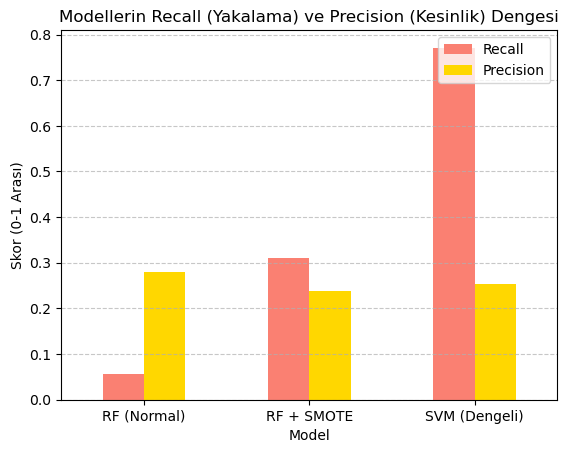

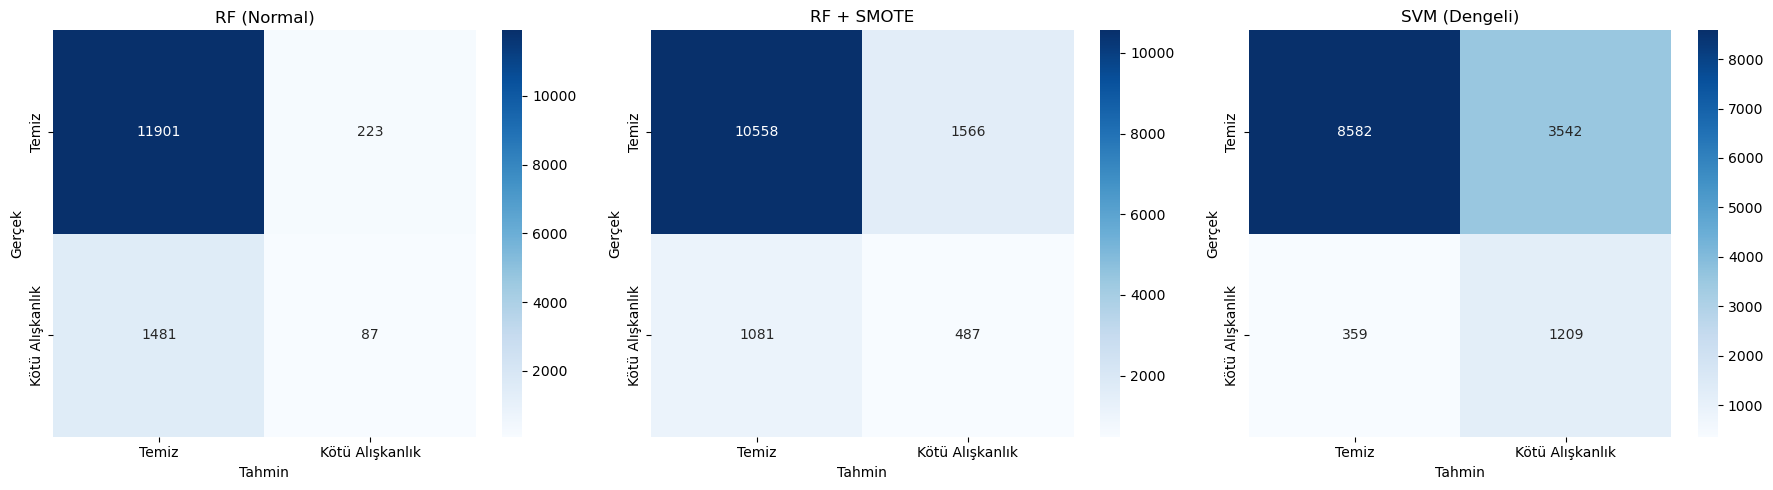


--- DETAYLI PERFORMANS TABLOSU ---
           Model  Accuracy    Recall  Precision  F1 Score
0    RF (Normal)  0.875548  0.055485   0.280645  0.092652
1     RF + SMOTE  0.806675  0.310587   0.237214  0.268986
2  SVM (Dengeli)  0.715089  0.771046   0.254473  0.382655


In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import accuracy_score, recall_score, f1_score, precision_score, confusion_matrix
from imblearn.over_sampling import SMOTE

# ---------------------------------------------------------
# 1. VERİ HAZIRLIĞI
# ---------------------------------------------------------
df = pd.read_csv('cardio_train.csv', sep=';')

if 'id' in df.columns: df.drop('id', axis=1, inplace=True)
df.drop_duplicates(inplace=True)
df = df[df['ap_lo'] <= df['ap_hi']]
df = df[(df['ap_hi'] >= 60) & (df['ap_hi'] <= 240)]
df = df[(df['ap_lo'] >= 30) & (df['ap_lo'] <= 150)]
df = df[(df['height'] >= 140) & (df['height'] <= 207)]
df = df[df['weight'] >= 40]

if df['age'].mean() > 150: df['age'] = (df['age'] / 365).astype(int)
df['gender'] = df['gender'].replace({1: 0, 2: 1})
df['bmi'] = df['weight'] / ((df['height'] / 100) ** 2)
df['pulse_pressure'] = df['ap_hi'] - df['ap_lo']
df['sigara_veya_alkol'] = (df['smoke'] | df['alco'])
df.drop(['smoke', 'alco'], axis=1, inplace=True)

X = df.drop(['sigara_veya_alkol'], axis=1)
y = df['sigara_veya_alkol']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# ---------------------------------------------------------
# 2. MODELLERİN EĞİTİMİ
# ---------------------------------------------------------
sonuclar = []

# Model 1: Random Forest (Normal)
print("1. RF (Normal) eğitiliyor...")
rf_base = RandomForestClassifier(n_estimators=100, random_state=42)
rf_base.fit(X_train, y_train)
y_pred_rf = rf_base.predict(X_test)
sonuclar.append({
    'Model': 'RF (Normal)',
    'Accuracy': accuracy_score(y_test, y_pred_rf),
    'Recall': recall_score(y_test, y_pred_rf),
    'Precision': precision_score(y_test, y_pred_rf, zero_division=0),
    'F1 Score': f1_score(y_test, y_pred_rf),
    'Confusion': confusion_matrix(y_test, y_pred_rf)
})

# Model 2: Random Forest + SMOTE
print("2. RF + SMOTE eğitiliyor...")
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)
rf_smote = RandomForestClassifier(n_estimators=100, random_state=42)
rf_smote.fit(X_train_smote, y_train_smote)
y_pred_smote = rf_smote.predict(X_test)
sonuclar.append({
    'Model': 'RF + SMOTE',
    'Accuracy': accuracy_score(y_test, y_pred_smote),
    'Recall': recall_score(y_test, y_pred_smote),
    'Precision': precision_score(y_test, y_pred_smote, zero_division=0),
    'F1 Score': f1_score(y_test, y_pred_smote),
    'Confusion': confusion_matrix(y_test, y_pred_smote)
})

# Model 3: SVM (Dengeli)
print("3. SVM (Dengeli) eğitiliyor...")
svm_model = make_pipeline(StandardScaler(), SVC(class_weight='balanced', random_state=42))
svm_model.fit(X_train, y_train)
y_pred_svm = svm_model.predict(X_test)
sonuclar.append({
    'Model': 'SVM (Dengeli)',
    'Accuracy': accuracy_score(y_test, y_pred_svm),
    'Recall': recall_score(y_test, y_pred_svm),
    'Precision': precision_score(y_test, y_pred_svm, zero_division=0),
    'F1 Score': f1_score(y_test, y_pred_svm),
    'Confusion': confusion_matrix(y_test, y_pred_svm)
})

# ---------------------------------------------------------
# 3. GÖRSELLEŞTİRME
# ---------------------------------------------------------
results_df = pd.DataFrame(sonuclar).drop('Confusion', axis=1)

# Grafik: Recall vs Precision (Trade-off)
plt.figure(figsize=(10, 6))
results_df.set_index('Model')[['Recall', 'Precision']].plot(kind='bar', color=['salmon', 'gold'])
plt.title('Modellerin Recall (Yakalama) ve Precision (Kesinlik) Dengesi')
plt.ylabel('Skor (0-1 Arası)')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(loc='upper right')
plt.show()

# Grafik: Matrisler
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, sonuc in enumerate(sonuclar):
    sns.heatmap(sonuc['Confusion'], annot=True, fmt='d', cmap='Blues', ax=axes[i],
                xticklabels=['Temiz', 'Kötü Alışkanlık'], yticklabels=['Temiz', 'Kötü Alışkanlık'])
    axes[i].set_title(sonuc['Model'])
    axes[i].set_xlabel('Tahmin')
    axes[i].set_ylabel('Gerçek')

plt.tight_layout()
plt.show()

print("\n--- DETAYLI PERFORMANS TABLOSU ---")
print(results_df)

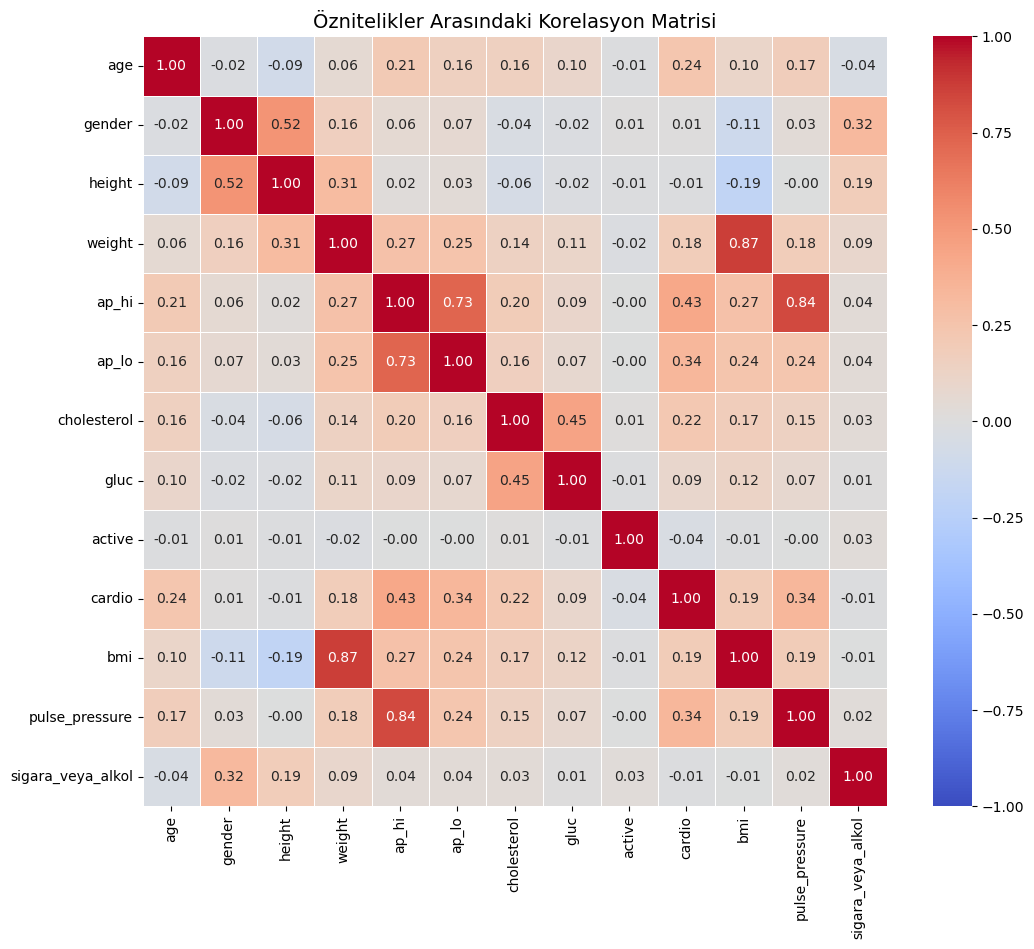

In [20]:
# ---------------------------------------------------------
# GÖRSEL 1: KORELASYON ISI HARİTASI (CORRELATION HEATMAP)
# ---------------------------------------------------------
plt.figure(figsize=(12, 10))

# Verisetindeki korelasyonu hesapla
corr = df.corr()

# Isı haritasını çiz
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', 
            linewidths=0.5, vmin=-1, vmax=1)

plt.title('Öznitelikler Arasındaki Korelasyon Matrisi', fontsize=14)
plt.show()

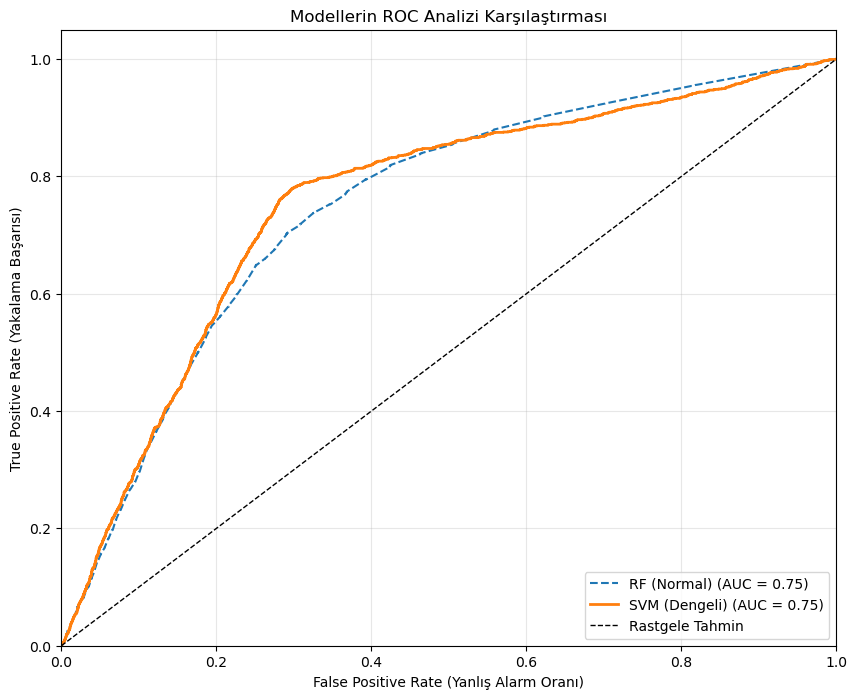

In [21]:
from sklearn.metrics import roc_curve, auc

# ---------------------------------------------------------
# GÖRSEL 2: ROC EĞRİSİ (MODEL KARŞILAŞTIRMASI)
# ---------------------------------------------------------
plt.figure(figsize=(10, 8))

# 1. Random Forest (Normal)
y_pred_prob_rf = rf_base.predict_proba(X_test)[:, 1] # Olasılık değerleri
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_pred_prob_rf)
roc_auc_rf = auc(fpr_rf, tpr_rf)
plt.plot(fpr_rf, tpr_rf, label=f'RF (Normal) (AUC = {roc_auc_rf:.2f})', linestyle='--')

# 2. SVM (Dengeli)
# SVM'de olasılık için decision_function kullanılır
y_pred_score_svm = svm_model.decision_function(X_test) 
fpr_svm, tpr_svm, _ = roc_curve(y_test, y_pred_score_svm)
roc_auc_svm = auc(fpr_svm, tpr_svm)
plt.plot(fpr_svm, tpr_svm, label=f'SVM (Dengeli) (AUC = {roc_auc_svm:.2f})', linewidth=2)

# Referans Çizgisi (Rastgele Tahmin)
plt.plot([0, 1], [0, 1], 'k--', lw=1, label='Rastgele Tahmin')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (Yanlış Alarm Oranı)')
plt.ylabel('True Positive Rate (Yakalama Başarısı)')
plt.title('Modellerin ROC Analizi Karşılaştırması')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()